In [5]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

stations_df = pd.read_csv(r"C:\Users\LIKITH REDDY\Applied data science\Project\stations_data.csv")

In [6]:
df = pd.read_csv(r"C:\Users\LIKITH REDDY\Applied data science\Project\rsu_training_45min.csv")

In [16]:
df = df.sort_values(by=['station_id', 'timestamp'])

# 1. Past Occupancy (T-1): What was the state in the previous interval?
df['prev_occupied_1'] = df.groupby('station_id')['occupied_slots'].shift(1)

# 2. Past Occupancy (T-2): Needed to calculate the trend of the past
df['prev_occupied_2'] = df.groupby('station_id')['occupied_slots'].shift(2)

# 3. FIX: occ_change (Momentum of the past: T-1 vs T-2)
# Tells the model: "Was it getting busier right before this moment?"
df['occ_change'] = df['prev_occupied_1'] - df['prev_occupied_2']

# 4. FIX: rolling_avg_3 (Stability of the past: Average of last 3 intervals before T)
df['rolling_avg_3'] = df.groupby('station_id')['occupied_slots'].shift(1).rolling(window=3).mean()

df = df.merge(
    stations_df[['station_id', 'station_bias']],
    on='station_id',
    how='left'
)

# Drop rows with NaNs (created by the shifts)
df_final = df.dropna()


C:\Users\LIKITH REDDY\AppData\Local\Temp\ipykernel_7076\406036092.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['timestamp'] = pd.to_datetime(


Model Evaluation Summary:
MAE  : 0.4678
RMSE : 0.6735
R²   : 0.9130


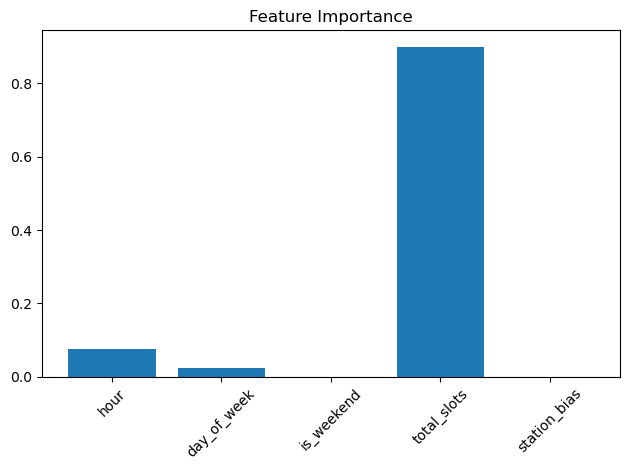

In [14]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

features = [
    'hour',
    'day_of_week',
    'is_weekend',
    'total_slots',
    'prev_occupied_1',
    'occ_change',
    'rolling_avg_3',
    'station_bias'
]

X = df_final[features]
y = df_final['occupied_slots']

df_final['timestamp'] = pd.to_datetime(
    df['timestamp'],
    format="%d-%m-%Y %H:%M"
)
cutoff = df_final['timestamp'].quantile(0.8)

train_df = df_final[df_final['timestamp'] <= cutoff]
test_df  = df_final[df_final['timestamp'] >  cutoff]

X_train = train_df[features]
y_train = train_df['occupied_slots']

X_test = test_df[features]
y_test = test_df['occupied_slots']


model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

preds = model.predict(X_test)

# Clip predictions to valid range
preds = np.clip(preds, 0, X_test['total_slots'])

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("Model Evaluation Summary:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure()
plt.bar(features, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==============================
# 1. BASELINE PREDICTION
# ==============================

# Use previous occupancy as prediction
baseline_preds = test_df['prev_occupied_1'].values

# Ensure predictions are within valid range
baseline_preds = np.clip(baseline_preds, 0, X_test['total_slots'])

# ==============================
# 2. EVALUATION
# ==============================

mae_base = mean_absolute_error(y_test, baseline_preds)
rmse_base = np.sqrt(mean_squared_error(y_test, baseline_preds))
r2_base = r2_score(y_test, baseline_preds)

print("Baseline Model (Persistence) Evaluation:")
print(f"MAE  : {mae_base:.4f}")
print(f"RMSE : {rmse_base:.4f}")
print(f"R²   : {r2_base:.4f}")

Baseline Model (Persistence) Evaluation:
MAE  : 0.5073
RMSE : 0.9708
R²   : 0.8193
